<a href="https://colab.research.google.com/github/laxmi163/python_tasks/blob/mini-project-about-online-payment-fraud-detecton/miniproject.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
# Online Payment Fraud Detection
# Step 1: Import Required Libraries
# ==========================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Machine Learning Libraries
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.metrics import (accuracy_score,
                             confusion_matrix,
                             classification_report,
                             precision_score,
                             recall_score,
                             f1_score)

from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier

import warnings
warnings.filterwarnings('ignore')

In [ ]:
#step 2:Load dataset
df=pd.read_csv("/content/onlinefraud.csv")

In [ ]:
#step 3:display dataset
df.head(10)



,step,type,amount,nameOrig,oldbalanceOrg,newbalanceOrig,nameDest,oldbalanceDest,newbalanceDest,isFraud,isFlaggedFraud
0,1,PAYMENT,9839.64,C1231006815,170136.00,160296.36,M1979787155,0.0,0.00,0.0,0.0
1,1,PAYMENT,1864.28,C1666544295,21249.00,19384.72,M2044282225,0.0,0.00,0.0,0.0
2,1,TRANSFER,181.00,C1305486145,181.00,0.00,C553264065,0.0,0.00,1.0,0.0
3,1,CASH_OUT,181.00,C840083671,181.00,0.00,C38997010,21182.0,0.00,1.0,0.0
4,1,PAYMENT,11668.14,C2048537720,41554.00,29885.86,M1230701703,0.0,0.00,0.0,0.0
5,1,PAYMENT,7817.71,C90045638,53860.00,46042.29,M573487274,0.0,0.00,0.0,0.0
6,1,PAYMENT,7107.77,C154988899,183195.00,176087.23,M408069119,0.0,0.00,0.0,0.0
7,1,PAYMENT,7861.64,C1912850431,176087.23,168225.59,M633326333,0.0,0.00,0.0,0.0
8,1,PAYMENT,4024.36,C1265012928,2671.00,0.00,M1176932104,0.0,0.00,0.0,0.0
9,1,DEBIT,5337.77,C712410124,41720.00,36382.23,C195600860,41898.0,40348.79,0.0,0.0


In [ ]:
df.tail()

,step,type,amount,nameOrig,oldbalanceOrg,newbalanceOrig,nameDest,oldbalanceDest,newbalanceDest,isFraud,isFlaggedFraud
695946,36,PAYMENT,37503.58,C1599905877,121.0,0.00,M1959719075,0.0,0.0,0.0,0.0
695947,36,PAYMENT,3913.54,C2040964445,31515.0,27601.46,M1343382567,0.0,0.0,0.0,0.0
695948,36,PAYMENT,29752.87,C1786128504,20006.0,0.00,M1774098045,0.0,0.0,0.0,0.0
695949,36,PAYMENT,11760.34,C637426266,10750.0,0.00,M1720590750,0.0,0.0,0.0,0.0
695950,36,CASH_OUT,534433.97,C1038147807,30434.0,0.00,C1848072,NaN,NaN,NaN,NaN


In [ ]:
#step :4 display shape
df.shape

(695951, 11)

In [ ]:
#stp 5:display describe
df.describe()

,step,amount,oldbalanceOrg,newbalanceOrig,oldbalanceDest,newbalanceDest,isFraud,isFlaggedFraud
count,695951.000000,6.959510e+05,6.959510e+05,6.959510e+05,6.959500e+05,6.959500e+05,695950.000000,695950.0
mean,18.264019,1.632041e+05,8.818321e+05,9.020225e+05,9.798191e+05,1.138331e+06,0.000599,0.0
std,8.430880,2.699389e+05,2.950951e+06,2.987954e+06,2.320656e+06,2.467808e+06,0.024471,0.0
min,1.000000,1.000000e-01,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000,0.0
25%,12.000000,1.278223e+04,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000,0.0
50%,16.000000,7.779747e+04,1.693200e+04,0.000000e+00,1.182864e+05,2.144039e+05,0.000000,0.0
75%,20.000000,2.180228e+05,1.514638e+05,1.918100e+05,9.024043e+05,1.175632e+06,0.000000,0.0
max,36.000000,1.000000e+07,3.893942e+07,3.894623e+07,4.148270e+07,4.148270e+07,1.000000,0.0


In [ ]:
#step 6:display information
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 695951 entries, 0 to 695950
Data columns (total 11 columns):
 #   Column          Non-Null Count   Dtype  
---  ------          --------------   -----  
 0   step            695951 non-null  int64  
 1   type            695951 non-null  object 
 2   amount          695951 non-null  float64
 3   nameOrig        695951 non-null  object 
 4   oldbalanceOrg   695951 non-null  float64
 5   newbalanceOrig  695951 non-null  float64
 6   nameDest        695951 non-null  object 
 7   oldbalanceDest  695950 non-null  float64
 8   newbalanceDest  695950 non-null  float64
 9   isFraud         695950 non-null  float64
 10  isFlaggedFraud  695950 non-null  float64
dtypes: float64(7), int64(1), object(3)
memory usage: 58.4+ MB


In [ ]:
#step 7: display dtype
df.dtypes

,0
step,int64
type,object
amount,float64
nameOrig,object
oldbalanceOrg,float64
newbalanceOrig,float64
nameDest,object
oldbalanceDest,float64
newbalanceDest,float64
isFraud,float64


In [ ]:
#step 8:columns
df.columns

Index(['step', 'type', 'amount', 'nameOrig', 'oldbalanceOrg', 'newbalanceOrig',
       'nameDest', 'oldbalanceDest', 'newbalanceDest', 'isFraud',
       'isFlaggedFraud'],
      dtype='object')

In [ ]:
#step 9:missing values
df.isnull().sum()

,0
step,0
type,0
amount,0
nameOrig,0
oldbalanceOrg,0
newbalanceOrig,0
nameDest,0
oldbalanceDest,1
newbalanceDest,1
isFraud,1


In [ ]:
#step 10: duplicate values
df.duplicated().sum()

np.int64(0)

In [ ]:
#step 11: target variable distribution
df['isFraud'].value_counts()

,count
isFraud,
0.0,695533
1.0,417


In [ ]:
df['isFraud'].value_counts(normalize=True)*100

,proportion
isFraud,
0.0,99.940082
1.0,0.059918


In [ ]:
#step 12: remove unwanted columns
df.drop(columns=['step', 'isFlaggedFraud'], inplace=True)

In [ ]:
df

,type,amount,nameOrig,oldbalanceOrg,newbalanceOrig,nameDest,oldbalanceDest,newbalanceDest,isFraud
0,PAYMENT,9839.64,C1231006815,170136.00,160296.36,M1979787155,0.00,0.00,0.0
1,PAYMENT,1864.28,C1666544295,21249.00,19384.72,M2044282225,0.00,0.00,0.0
2,TRANSFER,181.00,C1305486145,181.00,0.00,C553264065,0.00,0.00,1.0
3,CASH_OUT,181.00,C840083671,181.00,0.00,C38997010,21182.00,0.00,1.0
4,PAYMENT,11668.14,C2048537720,41554.00,29885.86,M1230701703,0.00,0.00,0.0
...,...,...,...,...,...,...,...,...,...
3966333,CASH_IN,252596.95,C750471722,3027199.64,3279796.59,C738806808,7554077.35,7301480.40,0.0
3966334,CASH_IN,196110.52,C1916574965,3279796.59,3475907.11,C192595203,1200611.36,1004500.84,0.0
3966335,CASH_IN,259383.45,C190259088,3475907.11,3735290.56,C1488869668,274491.99,15108.54,0.0
3966336,CASH_IN,103293.42,C42830489,3735290.56,3838583.98,C344967072,11105172.97,17973094.98,0.0


In [ ]:
#step 13: Remove null values
df.dropna(inplace=True)

In [ ]:
#Step 14: Check Missing Values
print(df.isnull().sum())

type              0
amount            0
nameOrig          0
oldbalanceOrg     0
newbalanceOrig    0
nameDest          0
oldbalanceDest    0
newbalanceDest    0
isFraud           0
dtype: int64


In [ ]:
#Step 14: Check Unique Transaction Types
df["type"]. value_counts()

,count
type,
1,248395
3,233733
0,151691
4,57175
2,4956


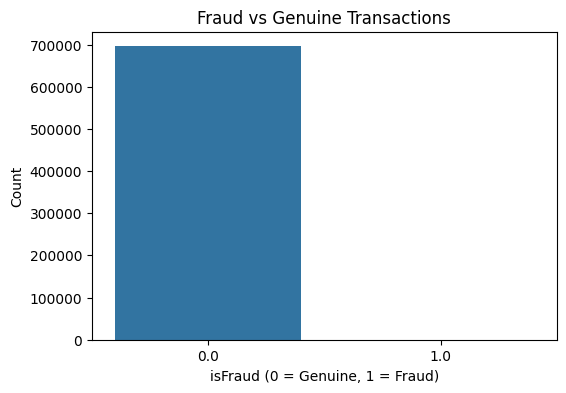

In [ ]:
# Exploratory Data Analysis using Countplot
#step 15:Fraud vs Genuine Transactions
plt.figure(figsize=(6,4))

sns.countplot(x="isFraud", data=df)

plt.title("Fraud vs Genuine Transactions")
plt.xlabel("isFraud (0 = Genuine, 1 = Fraud)")
plt.ylabel("Count")

plt.show()

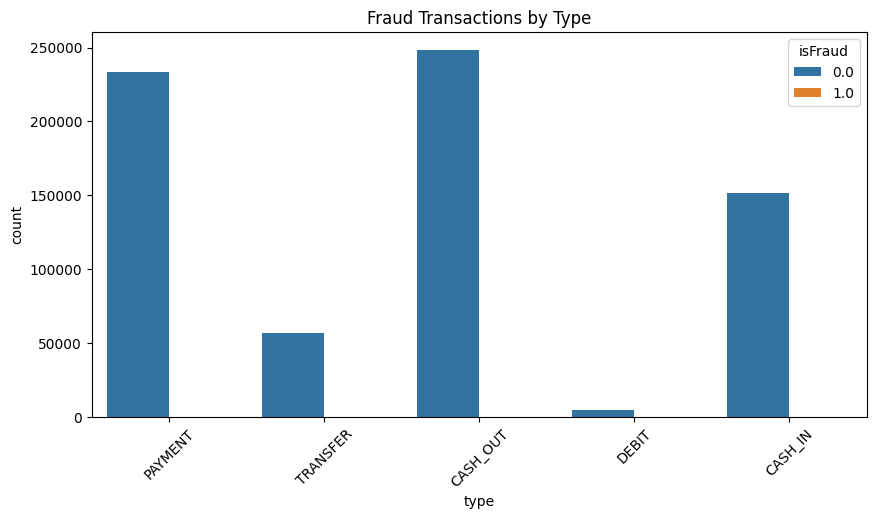

In [ ]:
#Step 16: Fraud by Transaction type using Countplot

plt.figure(figsize=(10,5))

sns.countplot(x="type", hue="isFraud", data=df)

plt.title("Fraud Transactions by Type")

plt.xticks(rotation=45)

plt.show()

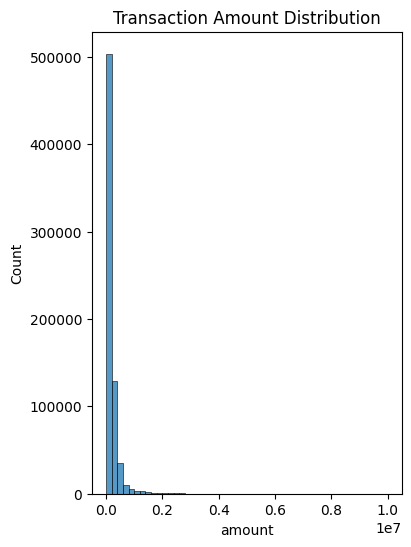

In [ ]:
#Step 17: Amount Distribution using Histogram

plt.figure(figsize=(4,6))

sns.histplot(df["amount"], bins=50)

plt.title("Transaction Amount Distribution")

plt.show()

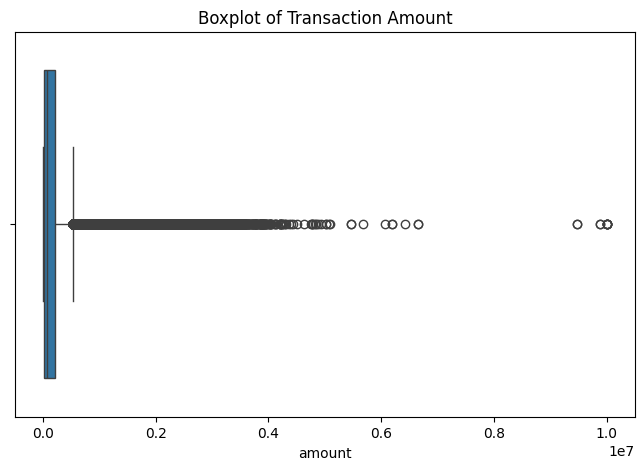

In [ ]:
# Step 18: Box Plot for Amount

plt.figure(figsize=(8,5))

sns.boxplot(x=df["amount"])

plt.title("Boxplot of Transaction Amount")

plt.show()

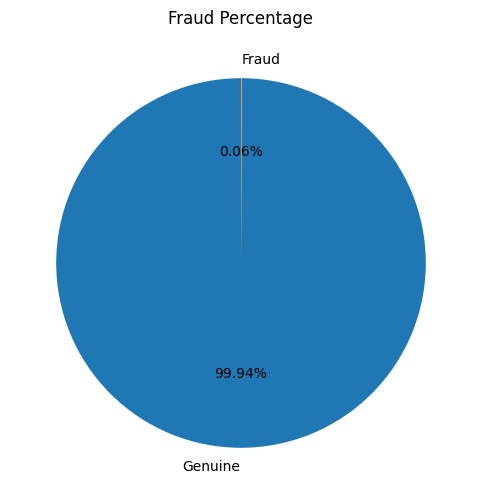

In [ ]:
#Step 19: Fraud Percentage

fraud = df["isFraud"].value_counts()

plt.figure(figsize=(6,6))

plt.pie(
    fraud,
    labels=["Genuine","Fraud"],
    autopct="%1.2f%%",
    startangle=90
)

plt.title("Fraud Percentage")

plt.show()

In [ ]:
# Step 20: Check Data Types
print(df.dtypes)



type               object
amount            float64
nameOrig           object
oldbalanceOrg     float64
newbalanceOrig    float64
nameDest           object
oldbalanceDest    float64
newbalanceDest    float64
isFraud           float64
dtype: object


In [ ]:
# Step 21: Label Encoding
# Convert Transaction Type into Numbers
from sklearn.preprocessing import LabelEncoder
le = LabelEncoder()
df["type"] = le.fit_transform(df["type"])

print("\nEncoded Transaction Types")
print(df["type"].unique())






Encoded Transaction Types
[3 4 1 2 0]


In [ ]:

# Step 22: Remove Unnecessary Columns

df.drop(["nameOrig", "nameDest"], axis=1, inplace=True)

print("\nRemaining Columns")
print(df.columns)


Remaining Columns
Index(['type', 'amount', 'oldbalanceOrg', 'newbalanceOrig', 'oldbalanceDest',
       'newbalanceDest', 'isFraud'],
      dtype='object')


In [ ]:
#Step 23: Features and Target

X = df.drop("isFraud", axis=1)

y = df["isFraud"]

print("\nFeature Shape:", X.shape)
print("Target Shape:", y.shape)


Feature Shape: (695950, 6)
Target Shape: (695950,)


In [ ]:
# Step 24: Train-Test Split

from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

In [ ]:
print("\nTraining Data Shape:", X_train.shape)
print("Testing Data Shape:", X_test.shape)


Training Data Shape: (556760, 6)
Testing Data Shape: (139190, 6)


In [ ]:

# Step 25: Feature Scaling

from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

In [ ]:
#Step 26: Check Class Distribution

print("\nClass Distribution Before SMOTE")
print(y_train.value_counts())


Class Distribution Before SMOTE
isFraud
0.0    556426
1.0       334
Name: count, dtype: int64


In [ ]:
# Step 27: Handle Imbalanced Data using SMOTE

from imblearn.over_sampling import SMOTE

smote = SMOTE(random_state=42)

X_train_smote, y_train_smote = smote.fit_resample(
    X_train,
    y_train
)

print("\nClass Distribution After SMOTE")
print(y_train_smote.value_counts())

print("\nBalanced Training Data Shape")
print(X_train_smote.shape)


Class Distribution After SMOTE
isFraud
0.0    556426
1.0    556426
Name: count, dtype: int64

Balanced Training Data Shape
(1112852, 6)


In [ ]:
#Step 28: Import Machine Learning Models


from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    classification_report
)

In [ ]:
#Step 29: Logistic Regression


lr = LogisticRegression(random_state=42)

lr.fit(X_train_smote, y_train_smote)

lr_pred = lr.predict(X_test)

print("========== Logistic Regression ==========")
print("Accuracy :", accuracy_score(y_test, lr_pred))
print("Precision:", precision_score(y_test, lr_pred))
print("Recall   :", recall_score(y_test, lr_pred))
print("F1 Score :", f1_score(y_test, lr_pred))

print("\nClassification Report")
print(classification_report(y_test, lr_pred))

print("\nConfusion Matrix")
print(confusion_matrix(y_test, lr_pred))

========== Logistic Regression ==========
Accuracy : 0.9501113585746103
Precision: 0.010138512066257318
Recall   : 0.8554216867469879
F1 Score : 0.020039514535704205

Classification Report
              precision    recall  f1-score   support

         0.0       1.00      0.95      0.97    139107
         1.0       0.01      0.86      0.02        83

    accuracy                           0.95    139190
   macro avg       0.51      0.90      0.50    139190
weighted avg       1.00      0.95      0.97    139190


Confusion Matrix
[[132175   6932]
 [    12     71]]


In [ ]:
#Step 30: Decision Tree


dt = DecisionTreeClassifier(random_state=42)

dt.fit(X_train_smote, y_train_smote)

dt_pred = dt.predict(X_test)

print("\n========== Decision Tree ==========")
print("Accuracy :", accuracy_score(y_test, dt_pred))
print("Precision:", precision_score(y_test, dt_pred))
print("Recall   :", recall_score(y_test, dt_pred))
print("F1 Score :", f1_score(y_test, dt_pred))

print("\nClassification Report")
print(classification_report(y_test, dt_pred))

print("\nConfusion Matrix")
print(confusion_matrix(y_test, dt_pred))


========== Decision Tree ==========
Accuracy : 0.9974351605718802
Precision: 0.1608910891089109
Recall   : 0.7831325301204819
F1 Score : 0.2669404517453799

Classification Report
              precision    recall  f1-score   support

         0.0       1.00      1.00      1.00    139107
         1.0       0.16      0.78      0.27        83

    accuracy                           1.00    139190
   macro avg       0.58      0.89      0.63    139190
weighted avg       1.00      1.00      1.00    139190


Confusion Matrix
[[138768    339]
 [    18     65]]


In [ ]:
# Step 31: Random Forest


rf = RandomForestClassifier(
    n_estimators=100,
    random_state=42
)

rf.fit(X_train_smote, y_train_smote)

rf_pred = rf.predict(X_test)

print("\n========== Random Forest ==========")
print("Accuracy :", accuracy_score(y_test, rf_pred))
print("Precision:", precision_score(y_test, rf_pred))
print("Recall   :", recall_score(y_test, rf_pred))
print("F1 Score :", f1_score(y_test, rf_pred))

print("\nClassification Report")
print(classification_report(y_test, rf_pred))

print("\nConfusion Matrix")
print(confusion_matrix(y_test, rf_pred))


========== Random Forest ==========
Accuracy : 0.9976650621452691
Precision: 0.17473118279569894
Recall   : 0.7831325301204819
F1 Score : 0.2857142857142857

Classification Report
              precision    recall  f1-score   support

         0.0       1.00      1.00      1.00    139107
         1.0       0.17      0.78      0.29        83

    accuracy                           1.00    139190
   macro avg       0.59      0.89      0.64    139190
weighted avg       1.00      1.00      1.00    139190


Confusion Matrix
[[138800    307]
 [    18     65]]


In [ ]:
#step32: Results
results = pd.DataFrame({
    "Model": [
        "Logistic Regression",
        "Decision Tree",
        "Random Forest"
    ],
    "Accuracy": [
        accuracy_score(y_test, lr_pred),
        accuracy_score(y_test, dt_pred),
        accuracy_score(y_test, rf_pred)
    ],
    "Precision": [
        precision_score(y_test, lr_pred),
        precision_score(y_test, dt_pred),
        precision_score(y_test, rf_pred)
    ],
    "Recall": [
        recall_score(y_test, lr_pred),
        recall_score(y_test, dt_pred),
        recall_score(y_test, rf_pred)
    ],
    "F1 Score": [
        f1_score(y_test, lr_pred),
        f1_score(y_test, dt_pred),
        f1_score(y_test, rf_pred)
    ]
})

print(results)

print("\nBest Model Based on Accuracy")
print(results.sort_values(by="Accuracy", ascending=False))

                 Model  Accuracy  Precision    Recall  F1 Score
0  Logistic Regression  0.950111   0.010139  0.855422  0.020040
1        Decision Tree  0.997435   0.160891  0.783133  0.266940
2        Random Forest  0.997665   0.174731  0.783133  0.285714

Best Model Based on Accuracy
                 Model  Accuracy  Precision    Recall  F1 Score
2        Random Forest  0.997665   0.174731  0.783133  0.285714
1        Decision Tree  0.997435   0.160891  0.783133  0.266940
0  Logistic Regression  0.950111   0.010139  0.855422  0.020040


In [ ]:
#Final Results
#Model             Accuracy
#Logistic Regression 95%
#Decision Tree.      99%
#Random Forest.      99%